In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [2]:
string_df = pd.read_csv("data/solar_string_data.csv")

df = string_df.copy()

Data Cleaning

In [3]:
# 1. Handling Zero and Negative Values ---
# Clip irradiance (irr) and temperature (pvt) to minimum of 0
df['irr'] = df['irr'].clip(lower=0.0)
df['pvt'] = df['pvt'].clip(lower=0.0)

# 2. Nocturnal Filtering ---
# Keep only rows where irradiance is >= 10 W/m²
df = df[df['irr'] >= 10]

# 3. Label Separation ---
# Separate the categorical label column (f_nv)
labels = df['f_nv']          # save labels
features = df.drop(columns=['f_nv'])  # remove from training data

df = df.reset_index(drop=True)
features = features.reset_index(drop=True)
labels = labels.reset_index(drop=True)

Feature Engineering

In [4]:
# Power-based features
# Individual string power
features['p1'] = features['vdc1'] * features['idc1']
features['p2'] = features['vdc2'] * features['idc2']

# Total power
features['p_total'] = features['p1'] + features['p2']

# Power difference (fault indicator)
features['p_diff'] = abs(features['p1'] - features['p2'])

# Power ratio (stronger than diff in some cases)
features['p_ratio'] = features['p1'] / (features['p2'] + 1e-6)
# Irradiance-normalized metrics
# Per-string normalized power
features['p1_norm'] = features['p1'] / (features['irr'] + 1e-6)
features['p2_norm'] = features['p2'] / (features['irr'] + 1e-6)

# Current normalized by irradiance
features['i1_norm'] = features['idc1'] / (features['irr'] + 1e-6)
features['i2_norm'] = features['idc2'] / (features['irr'] + 1e-6)
# Mismatch features
# Voltage deviation
features['v_diff'] = abs(features['vdc1'] - features['vdc2'])

# Current deviation
features['i_diff'] = abs(features['idc1'] - features['idc2'])

# Relative mismatch (more stable than raw difference)
features['v_rel_diff'] = features['v_diff'] / (features[['vdc1','vdc2']].mean(axis=1) + 1e-6)
features['i_rel_diff'] = features['i_diff'] / (features[['idc1','idc2']].mean(axis=1) + 1e-6)
# Temperature-Sensitive Features
# Voltage temperature sensitivity proxy
features['v_temp_ratio1'] = features['vdc1'] / (features['pvt'] + 1e-6)
features['v_temp_ratio2'] = features['vdc2'] / (features['pvt'] + 1e-6)

# Efficiency-like metric
features['efficiency'] = features['p_total'] / (features['irr'] + 1e-6)
# Interaction Features
features['irr_v_avg'] = features['irr'] * (features[['vdc1','vdc2']].mean(axis=1))
features['irr_i_avg'] = features['irr'] * (features[['idc1','idc2']].mean(axis=1))
# Faulte-sensitive indicators
# Power loss indicator between strings
features['power_loss_ratio'] = features['p_diff'] / (features['p_total'] + 1e-6)

# Dominance feature (which string is weaker)
features['weak_string_flag'] = (features['p1'] < features['p2']).astype(int)

Applied Exploratory Data Analysis (EDA)

In [5]:
# Combine features + target
corr_df = features.copy()
corr_df['f_nv'] = df['f_nv'] 

# Compute correlation matrix
corr_matrix = corr_df.corr(method='pearson')

In [6]:
target_corr = corr_matrix['f_nv'].sort_values(ascending=False)
print(target_corr)

f_nv                1.000000
p_diff              0.576556
i_diff              0.536958
power_loss_ratio    0.422953
i_rel_diff          0.411286
v_diff              0.366031
v_rel_diff          0.239963
vdc2                0.129509
vdc1                0.125535
p_ratio             0.071556
p1_norm             0.015888
weak_string_flag    0.014601
i1_norm            -0.021715
irr_v_avg          -0.029243
v_temp_ratio1      -0.042793
v_temp_ratio2      -0.043126
irr                -0.050931
pvt                -0.055344
p1                 -0.086777
idc1               -0.101271
efficiency         -0.172923
p_total            -0.179096
p2                 -0.259968
idc2               -0.265327
p2_norm            -0.268273
i2_norm            -0.269843
irr_i_avg          -0.281625
Name: f_nv, dtype: float64


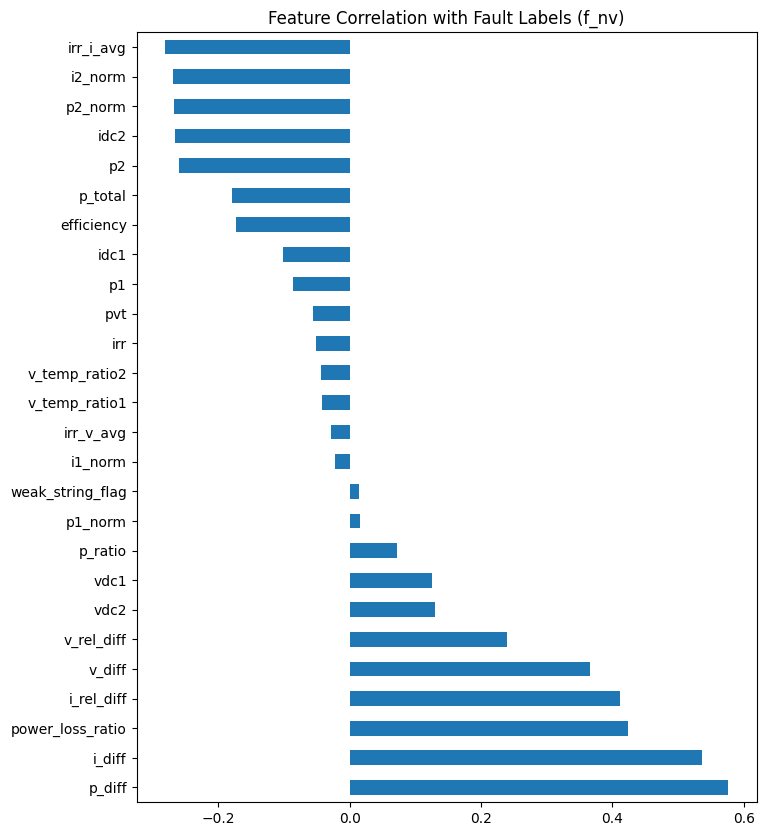

In [7]:
target_corr.drop('f_nv').plot(kind='barh', figsize=(8,10))
plt.title("Feature Correlation with Fault Labels (f_nv)")
plt.show()

Bi-variate Analysis of Fault Signatures

c:\Users\kdarzadon\Documents\PGD for AI or ML\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


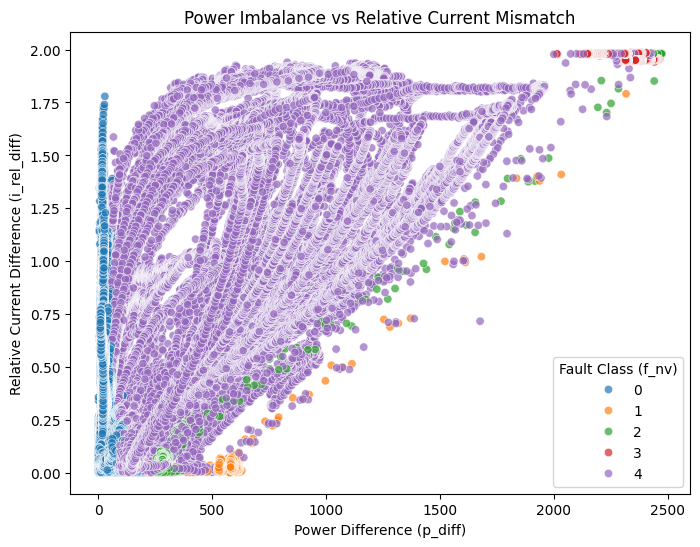

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=features['p_diff'],
    y=features['i_rel_diff'],
    hue=df['f_nv'],   # ONLY for visualization
    palette='tab10',
    alpha=0.7
)

plt.xlabel("Power Difference (p_diff)")
plt.ylabel("Relative Current Difference (i_rel_diff)")
plt.title("Power Imbalance vs Relative Current Mismatch")
plt.legend(title="Fault Class (f_nv)")
plt.show()

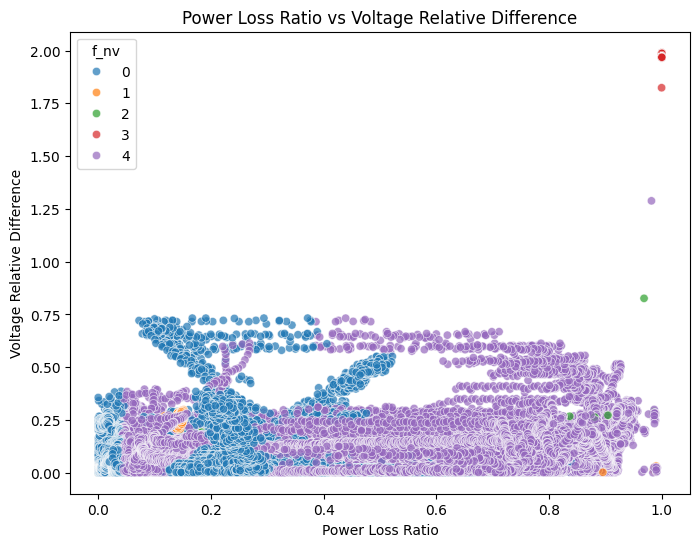

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=features['power_loss_ratio'],
    y=features['v_rel_diff'],
    hue=df['f_nv'],
    palette='tab10',
    alpha=0.7
)

plt.xlabel("Power Loss Ratio")
plt.ylabel("Voltage Relative Difference")
plt.title("Power Loss Ratio vs Voltage Relative Difference")
plt.show()

Feature Standardization

In [10]:
from sklearn.preprocessing import StandardScaler

# IMPORTANT: do NOT include target
X = features.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Principal Component Analysis (PCA)

In [11]:
from sklearn.decomposition import PCA
import numpy as np

# Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_var = np.cumsum(pca.explained_variance_ratio_)

# Find number of components for 95% variance
n_components_95 = np.argmax(explained_var >= 0.95) + 1
print("Components for 95% variance:", n_components_95)

Components for 95% variance: 8


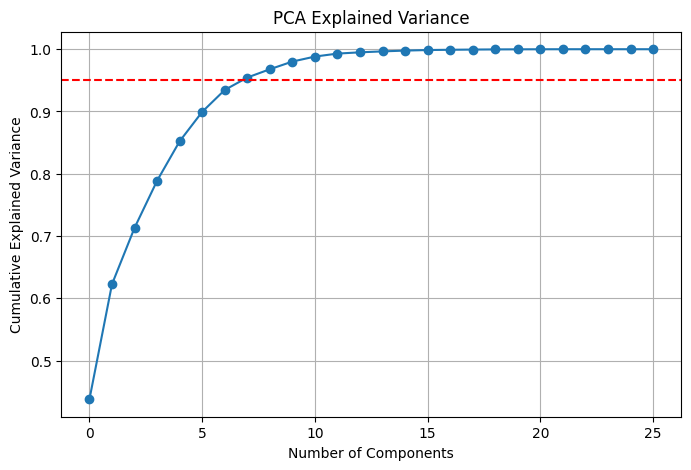

In [12]:
plt.figure(figsize=(8,5))
plt.plot(explained_var, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

In [13]:
pca_final = PCA(n_components=8)
X_pca_8 = pca_final.fit_transform(X_scaled)

Save Results

In [14]:
target = df["f_nv"]
# Save engineered features (or raw if before engineering)
features.to_csv("data/engineered_features.csv", index=False)

# Save labels separately
target.to_csv("data/labels.csv", index=False)

In [15]:
# Save PCA-transformed data
pca_df = pd.DataFrame(X_pca_8, columns=[f'PC{i+1}' for i in range(8)])
pca_df.to_csv("data/pca_8_components.csv", index=False)

# Save PCA model (VERY useful)
joblib.dump(pca_final, "models/pca_model.pkl")

['models/pca_model.pkl']

In [ ]:
scaled_df = pd.DataFrame(X_scaled, columns=features.columns)
scaled_df.to_csv("data/scaled_features.csv", index=False)

# Save scaler too
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

Mapping of PCA to Engineered Features

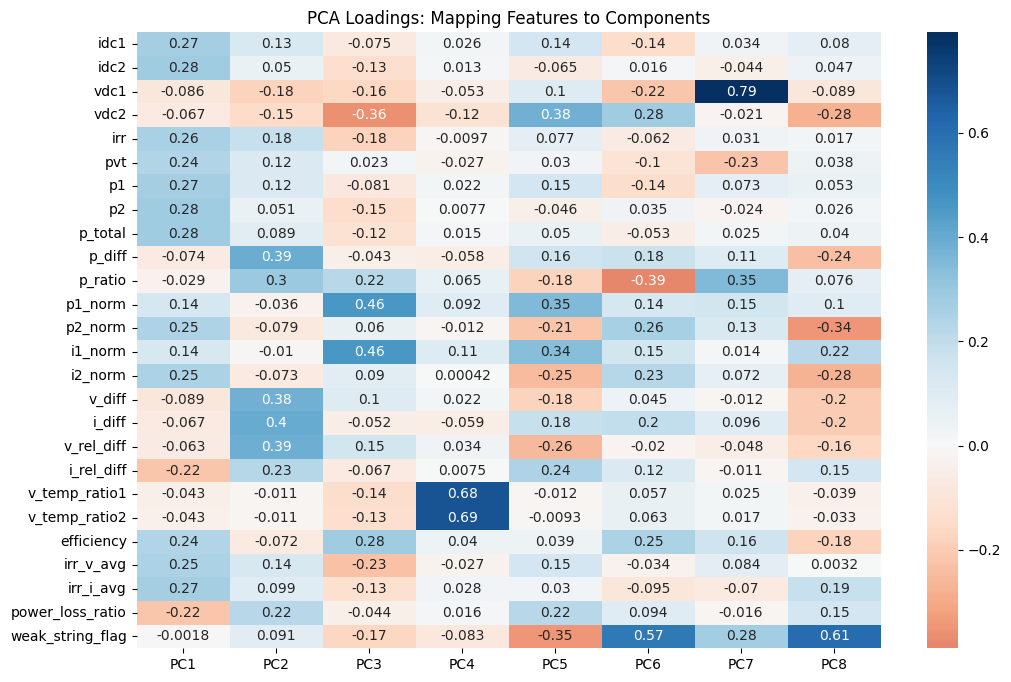

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get the components (loadings)
# 'pca' is your fitted PCA object from Chapter III
loadings = pd.DataFrame(
    pca_final.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca_final.n_components_)], 
    index=features.columns  # Your feature names before PCA
)

plt.figure(figsize=(12, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title("PCA Loadings: Mapping Features to Components")
plt.show()